# Semana 8 — MDP de horizonte infinito: VI, PI y LP

En esta sesión estudiamos tres métodos exactos para resolver MDP de horizonte infinito con factor de descuento $\gamma<1$:

- **Iteración de Valor (VI)**.
- **Iteración de Política (PI)**.
- **Programación Lineal (LP)**.

La dificultad central de esta semana es comprender cómo cada método usa las ecuaciones de Bellman. El código se escribe con ciclos, condicionales, arreglos de NumPy y funciones sencillas, siguiendo el estilo de los cuadernos anteriores.

> **Conexión con la semana 7:** en backward induction recorríamos las épocas desde el final hasta el comienzo. En horizonte infinito no existe una última época conocida. Buscamos una función $V^*$ que permanezca igual después de aplicar nuevamente el operador de Bellman.

---
## Fundamentos teóricos

### Ecuación de Bellman de optimalidad

Para un MDP $(\mathcal S,\mathcal A,P,r,\gamma)$:

$$
V^*(s)
=
\max_{a\in\mathcal A}
\left[
r(s,a)
+
\gamma
\sum_{s'}
P(s'\mid s,a)V^*(s')
\right].
$$

### Iteración de Valor

Partimos de un vector inicial $V^{(0)}$ y repetimos:

$$
V^{(k+1)}(s)
=
\max_a
\left[
r(s,a)
+
\gamma
\sum_{s'}
P(s'\mid s,a)V^{(k)}(s')
\right].
$$

### Iteración de Política

Alternamos dos pasos:

1. **Evaluación:** resolver $(I-\gamma P^\pi)V^\pi=r^\pi$.
2. **Mejora:** elegir en cada estado la acción con mayor valor.

### Programación Lineal

La función óptima también se obtiene resolviendo:

$$
\min_V \sum_s V_s
$$

sujeto a:

$$
V_s
\geq
r(s,a)
+
\gamma
\sum_{s'}P(s'\mid s,a)V_{s'}
\qquad
\forall(s,a).
$$

Los tres métodos deben producir el mismo $V^*$ y una política óptima equivalente.

---
## Preparación del entorno

Ejecute las celdas de arriba hacia abajo. La instalación de `jmarkov` se utiliza solamente para verificar resultados al final de algunos ejercicios.

In [1]:
!pip install jmarkov

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import linprog

---
## Herramienta: `np.argmax`

Para cada estado calcularemos un valor por acción. Necesitamos distinguir:

- `np.max(valores)`: devuelve el mayor valor.
- `np.argmax(valores)`: devuelve la posición donde se encuentra ese mayor valor.

La posición permite identificar la acción óptima.

In [3]:
valores_ejemplo = np.array([4.2, 6.8])

mejor_valor = np.max(valores_ejemplo)
indice_mejor_accion = np.argmax(valores_ejemplo)

print("Mejor valor:", mejor_valor)
print("Índice de la mejor acción:", indice_mejor_accion)

Mejor valor: 6.8
Índice de la mejor acción: 1


---
# Ejercicio 1 — Gestión de activos: reemplazo de un generador

Energía Andes S.A.S. observa el estado de un generador y decide entre **Mantener** y **Reemplazar**.

Estados:

$$
\mathcal S=
\{\text{Nuevo},\text{Bueno},\text{Regular},\text{Malo}\}.
$$

Acciones:

$$
\mathcal A=
\{\text{Mantener},\text{Reemplazar}\}.
$$

Matrices de transición:

$$
P^{(M)}
=
\begin{pmatrix}
0.85&0.15&0&0\\
0&0.80&0.20&0\\
0&0&0.70&0.30\\
0&0&0&1
\end{pmatrix},
$$

$$
P^{(R)}
=
\begin{pmatrix}
1&0&0&0\\
0.85&0.15&0&0\\
0.85&0.15&0&0\\
0.85&0.15&0&0
\end{pmatrix}.
$$

La primera fila de $P^{(R)}$ es una transición ficticia válida. Reemplazar desde Nuevo se hace infactible mediante una recompensa muy negativa.

Retornos:

| Estado | Mantener | Reemplazar |
|:---|---:|---:|
| Nuevo | 100 | -10000 |
| Bueno | 80 | -20 |
| Regular | 50 | -20 |
| Malo | 20 | -20 |

Factor de descuento: $\gamma=0.90$.

In [4]:
estados_generador = np.array([
    "Nuevo",
    "Bueno",
    "Regular",
    "Malo"
])

acciones_generador = np.array([
    "Mantener",
    "Reemplazar"
])

gamma_generador = 0.90

P_mantener = np.array([
    [0.85, 0.15, 0.00, 0.00],
    [0.00, 0.80, 0.20, 0.00],
    [0.00, 0.00, 0.70, 0.30],
    [0.00, 0.00, 0.00, 1.00]
])

P_reemplazar = np.array([
    [1.00, 0.00, 0.00, 0.00],
    [0.85, 0.15, 0.00, 0.00],
    [0.85, 0.15, 0.00, 0.00],
    [0.85, 0.15, 0.00, 0.00]
])

matrices_generador = [
    P_mantener,
    P_reemplazar
]

retornos_generador = np.array([
    [100.0, -10000.0],
    [ 80.0,    -20.0],
    [ 50.0,    -20.0],
    [ 20.0,    -20.0]
])

numero_estados_generador = len(estados_generador)
numero_acciones_generador = len(acciones_generador)

for indice_accion in range(numero_acciones_generador):
    print("Acción:", acciones_generador[indice_accion])

    for estado_actual in range(numero_estados_generador):
        suma_fila = matrices_generador[indice_accion][
            estado_actual, :
        ].sum()

        print(
            "  Estado",
            estados_generador[estado_actual],
            "- suma de la fila:",
            round(float(suma_fila), 6)
        )

Acción: Mantener
  Estado Nuevo - suma de la fila: 1.0
  Estado Bueno - suma de la fila: 1.0
  Estado Regular - suma de la fila: 1.0
  Estado Malo - suma de la fila: 1.0
Acción: Reemplazar
  Estado Nuevo - suma de la fila: 1.0
  Estado Bueno - suma de la fila: 1.0
  Estado Regular - suma de la fila: 1.0
  Estado Malo - suma de la fila: 1.0


## 1.1 Una actualización de Bellman

Comenzamos con:

$$
V^{(0)}=[0,0,0,0].
$$

Para cada estado calculamos un valor por acción. Como $V^{(0)}=0$, en la primera actualización la parte de continuación vale cero. El código se escribe completo antes de pasar al ciclo general.

In [5]:
valor_inicial = np.zeros(numero_estados_generador)

valores_primera_iteracion = np.zeros(
    (numero_estados_generador, numero_acciones_generador)
)

for estado_actual in range(numero_estados_generador):

    for accion_actual in range(numero_acciones_generador):

        continuacion = 0.0

        for estado_siguiente in range(numero_estados_generador):

            probabilidad = matrices_generador[accion_actual][
                estado_actual,
                estado_siguiente
            ]

            continuacion = (
                continuacion
                + probabilidad
                * valor_inicial[estado_siguiente]
            )

        valores_primera_iteracion[
            estado_actual,
            accion_actual
        ] = (
            retornos_generador[
                estado_actual,
                accion_actual
            ]
            + gamma_generador * continuacion
        )

valor_primera_iteracion = np.zeros(numero_estados_generador)
politica_primera_iteracion = np.zeros(
    numero_estados_generador,
    dtype=int
)

for estado_actual in range(numero_estados_generador):

    valor_primera_iteracion[estado_actual] = np.max(
        valores_primera_iteracion[estado_actual, :]
    )

    politica_primera_iteracion[estado_actual] = np.argmax(
        valores_primera_iteracion[estado_actual, :]
    )

print("Valores por acción en la primera iteración:")
print(valores_primera_iteracion)

print("\nV^(1):", valor_primera_iteracion)

print("\nAcciones elegidas en la primera iteración:")

for estado_actual in range(numero_estados_generador):

    indice_accion = politica_primera_iteracion[
        estado_actual
    ]

    print(
        estados_generador[estado_actual],
        "->",
        acciones_generador[indice_accion]
    )

Valores por acción en la primera iteración:
[[   100. -10000.]
 [    80.    -20.]
 [    50.    -20.]
 [    20.    -20.]]

V^(1): [100.  80.  50.  20.]

Acciones elegidas en la primera iteración:
Nuevo -> Mantener
Bueno -> Mantener
Regular -> Mantener
Malo -> Mantener


## 1.2 Iteración de Valor

El contador se incrementa cada vez que se aplica el operador de Bellman. Después de converger, recalculamos los valores por acción usando el valor final antes de extraer la política.

In [6]:
epsilon_generador = 0.00000001

umbral_generador = (
    epsilon_generador
    * (1 - gamma_generador)
    / (2 * gamma_generador)
)

valor_vi_generador = np.zeros(numero_estados_generador)
historial_cambios_generador = []
numero_iteraciones_vi_generador = 0

inicio_tiempo = time.perf_counter()

while True:

    numero_iteraciones_vi_generador = (
        numero_iteraciones_vi_generador + 1
    )

    valores_por_accion = np.zeros(
        (numero_estados_generador, numero_acciones_generador)
    )

    for estado_actual in range(numero_estados_generador):

        for accion_actual in range(numero_acciones_generador):

            continuacion = 0.0

            for estado_siguiente in range(
                numero_estados_generador
            ):

                probabilidad = matrices_generador[
                    accion_actual
                ][estado_actual, estado_siguiente]

                continuacion = (
                    continuacion
                    + probabilidad
                    * valor_vi_generador[estado_siguiente]
                )

            valores_por_accion[
                estado_actual,
                accion_actual
            ] = (
                retornos_generador[
                    estado_actual,
                    accion_actual
                ]
                + gamma_generador * continuacion
            )

    valor_nuevo = np.zeros(numero_estados_generador)

    for estado_actual in range(numero_estados_generador):

        valor_nuevo[estado_actual] = np.max(
            valores_por_accion[estado_actual, :]
        )

    cambio_maximo = np.max(
        np.abs(valor_nuevo - valor_vi_generador)
    )

    historial_cambios_generador.append(cambio_maximo)

    valor_vi_generador = valor_nuevo.copy()

    if cambio_maximo < umbral_generador:
        break

tiempo_vi_generador = (
    time.perf_counter() - inicio_tiempo
) * 1000

# Recalcular los valores por acción usando V final
valores_finales_por_accion = np.zeros(
    (numero_estados_generador, numero_acciones_generador)
)

for estado_actual in range(numero_estados_generador):

    for accion_actual in range(numero_acciones_generador):

        continuacion = 0.0

        for estado_siguiente in range(numero_estados_generador):

            probabilidad = matrices_generador[accion_actual][
                estado_actual,
                estado_siguiente
            ]

            continuacion = (
                continuacion
                + probabilidad
                * valor_vi_generador[estado_siguiente]
            )

        valores_finales_por_accion[
            estado_actual,
            accion_actual
        ] = (
            retornos_generador[
                estado_actual,
                accion_actual
            ]
            + gamma_generador * continuacion
        )

politica_vi_generador = np.zeros(
    numero_estados_generador,
    dtype=int
)

for estado_actual in range(numero_estados_generador):

    politica_vi_generador[estado_actual] = np.argmax(
        valores_finales_por_accion[estado_actual, :]
    )

print(
    "VI convergió en",
    numero_iteraciones_vi_generador,
    "actualizaciones de Bellman."
)

print("Tiempo observado:", round(tiempo_vi_generador, 3), "ms")

print("\nValor óptimo aproximado:")

for estado_actual in range(numero_estados_generador):

    print(
        estados_generador[estado_actual],
        ":",
        round(float(valor_vi_generador[estado_actual]), 4)
    )

print("\nPolítica obtenida con VI:")

for estado_actual in range(numero_estados_generador):

    indice_accion = politica_vi_generador[estado_actual]

    print(
        estados_generador[estado_actual],
        "->",
        acciones_generador[indice_accion]
    )

VI convergió en 245 actualizaciones de Bellman.
Tiempo observado: 7.978 ms

Valor óptimo aproximado:
Nuevo : 864.6747
Bueno : 764.4337
Regular : 744.6747
Malo : 744.6747

Política obtenida con VI:
Nuevo -> Mantener
Bueno -> Mantener
Regular -> Reemplazar
Malo -> Reemplazar


### Visualización proporcionada

Esta celda se entrega completa. El código de Matplotlib **no hace parte de los contenidos de programación evaluados**. Concéntrese en interpretar cómo disminuye el cambio máximo y cuándo cruza el umbral de parada.

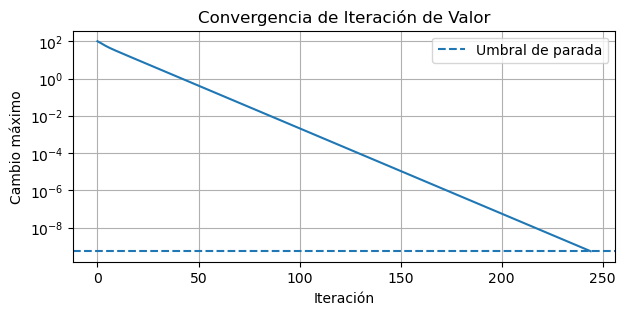

In [7]:
plt.figure(figsize=(7, 3))

plt.semilogy(historial_cambios_generador)

plt.axhline(
    umbral_generador,
    linestyle="--",
    label="Umbral de parada"
)

plt.xlabel("Iteración")
plt.ylabel("Cambio máximo")
plt.title("Convergencia de Iteración de Valor")
plt.legend()
plt.grid()
plt.show()

## 1.3 Iteración de Política

`np.linalg.solve(A,b)` resuelve el sistema lineal $Ax=b$. No estudiaremos internamente el método numérico; el objetivo es construir correctamente $P^\pi$ y $r^\pi$.

In [8]:
politica_pi_generador = np.zeros(
    numero_estados_generador,
    dtype=int
)

numero_evaluaciones_generador = 0

inicio_tiempo = time.perf_counter()

while True:

    matriz_politica = np.zeros(
        (numero_estados_generador, numero_estados_generador)
    )

    retorno_politica = np.zeros(numero_estados_generador)

    for estado_actual in range(numero_estados_generador):

        accion_elegida = politica_pi_generador[
            estado_actual
        ]

        matriz_politica[
            estado_actual, :
        ] = matrices_generador[
            accion_elegida
        ][estado_actual, :]

        retorno_politica[
            estado_actual
        ] = retornos_generador[
            estado_actual,
            accion_elegida
        ]

    identidad = np.eye(numero_estados_generador)

    valor_pi_generador = np.linalg.solve(
        identidad
        - gamma_generador * matriz_politica,
        retorno_politica
    )

    numero_evaluaciones_generador = (
        numero_evaluaciones_generador + 1
    )

    valores_por_accion = np.zeros(
        (numero_estados_generador, numero_acciones_generador)
    )

    for estado_actual in range(numero_estados_generador):

        for accion_actual in range(numero_acciones_generador):

            continuacion = 0.0

            for estado_siguiente in range(
                numero_estados_generador
            ):

                continuacion = (
                    continuacion
                    + matrices_generador[accion_actual][
                        estado_actual,
                        estado_siguiente
                    ]
                    * valor_pi_generador[estado_siguiente]
                )

            valores_por_accion[
                estado_actual,
                accion_actual
            ] = (
                retornos_generador[
                    estado_actual,
                    accion_actual
                ]
                + gamma_generador * continuacion
            )

    politica_nueva = np.zeros(
        numero_estados_generador,
        dtype=int
    )

    for estado_actual in range(numero_estados_generador):

        politica_nueva[estado_actual] = np.argmax(
            valores_por_accion[estado_actual, :]
        )

    politica_estable = True

    for estado_actual in range(numero_estados_generador):

        if (
            politica_nueva[estado_actual]
            != politica_pi_generador[estado_actual]
        ):
            politica_estable = False

    politica_pi_generador = politica_nueva.copy()

    if politica_estable:
        break

tiempo_pi_generador = (
    time.perf_counter() - inicio_tiempo
) * 1000

print(
    "PI convergió en",
    numero_evaluaciones_generador,
    "evaluaciones de política."
)

print("Tiempo observado:", round(tiempo_pi_generador, 3), "ms")

PI convergió en 3 evaluaciones de política.
Tiempo observado: 3.732 ms


## 1.4 Programación Lineal

Primero construimos una restricción de Bellman por cada par estado–acción. El solver `linprog` se utiliza como herramienta numérica proporcionada: se evalúa la formulación del LP, no el funcionamiento interno del solver HiGHS.

In [9]:
numero_restricciones_generador = (
    numero_estados_generador
    * numero_acciones_generador
)

A_ub_generador = np.zeros(
    (
        numero_restricciones_generador,
        numero_estados_generador
    )
)

b_ub_generador = np.zeros(
    numero_restricciones_generador
)

fila_restriccion = 0

for estado_actual in range(numero_estados_generador):

    for accion_actual in range(numero_acciones_generador):

        A_ub_generador[
            fila_restriccion,
            estado_actual
        ] = -1.0

        for estado_siguiente in range(
            numero_estados_generador
        ):

            A_ub_generador[
                fila_restriccion,
                estado_siguiente
            ] = (
                A_ub_generador[
                    fila_restriccion,
                    estado_siguiente
                ]
                + gamma_generador
                * matrices_generador[accion_actual][
                    estado_actual,
                    estado_siguiente
                ]
            )

        b_ub_generador[fila_restriccion] = (
            -retornos_generador[
                estado_actual,
                accion_actual
            ]
        )

        fila_restriccion = fila_restriccion + 1

objetivo_lp = np.ones(numero_estados_generador)

limites_lp = [
    (None, None)
] * numero_estados_generador

inicio_tiempo = time.perf_counter()

resultado_lp_generador = linprog(
    objetivo_lp,
    A_ub=A_ub_generador,
    b_ub=b_ub_generador,
    bounds=limites_lp,
    method="highs"
)

tiempo_lp_generador = (
    time.perf_counter() - inicio_tiempo
) * 1000

if resultado_lp_generador.success:
    valor_lp_generador = resultado_lp_generador.x
else:
    raise RuntimeError(
        "El solver LP no encontró una solución óptima."
    )

valores_lp_por_accion = np.zeros(
    (numero_estados_generador, numero_acciones_generador)
)

for estado_actual in range(numero_estados_generador):

    for accion_actual in range(numero_acciones_generador):

        continuacion = 0.0

        for estado_siguiente in range(numero_estados_generador):

            continuacion = (
                continuacion
                + matrices_generador[accion_actual][
                    estado_actual,
                    estado_siguiente
                ]
                * valor_lp_generador[estado_siguiente]
            )

        valores_lp_por_accion[
            estado_actual,
            accion_actual
        ] = (
            retornos_generador[
                estado_actual,
                accion_actual
            ]
            + gamma_generador * continuacion
        )

politica_lp_generador = np.zeros(
    numero_estados_generador,
    dtype=int
)

for estado_actual in range(numero_estados_generador):

    politica_lp_generador[estado_actual] = np.argmax(
        valores_lp_por_accion[estado_actual, :]
    )

print("Estado del solver:", resultado_lp_generador.message)
print("Tiempo observado:", round(tiempo_lp_generador, 3), "ms")

Estado del solver: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Tiempo observado: 10.98 ms


## 1.5 Comparación de los tres métodos

Los tiempos medidos son **ilustrativos** y pueden cambiar entre ejecuciones. Para problemas tan pequeños no permiten concluir qué algoritmo será siempre más rápido.

In [10]:
print("Comparación de valores y políticas")

for estado_actual in range(numero_estados_generador):

    accion_vi = acciones_generador[
        politica_vi_generador[estado_actual]
    ]

    accion_pi = acciones_generador[
        politica_pi_generador[estado_actual]
    ]

    accion_lp = acciones_generador[
        politica_lp_generador[estado_actual]
    ]

    print("\nEstado:", estados_generador[estado_actual])

    print(
        "  V por VI:",
        round(float(valor_vi_generador[estado_actual]), 4)
    )

    print(
        "  V por PI:",
        round(float(valor_pi_generador[estado_actual]), 4)
    )

    print(
        "  V por LP:",
        round(float(valor_lp_generador[estado_actual]), 4)
    )

    print("  Política VI:", accion_vi)
    print("  Política PI:", accion_pi)
    print("  Política LP:", accion_lp)

diferencia_vi_pi = np.max(
    np.abs(valor_vi_generador - valor_pi_generador)
)

diferencia_vi_lp = np.max(
    np.abs(valor_vi_generador - valor_lp_generador)
)

print("\nDiferencia máxima VI-PI:", diferencia_vi_pi)
print("Diferencia máxima VI-LP:", diferencia_vi_lp)

print("\nActualizaciones de Bellman en VI:",
      numero_iteraciones_vi_generador)

print("Evaluaciones de política en PI:",
      numero_evaluaciones_generador)

print("Restricciones del LP:",
      numero_restricciones_generador)

Comparación de valores y políticas

Estado: Nuevo
  V por VI: 864.6747
  V por PI: 864.6747
  V por LP: 864.6747
  Política VI: Mantener
  Política PI: Mantener
  Política LP: Mantener

Estado: Bueno
  V por VI: 764.4337
  V por PI: 764.4337
  V por LP: 764.4337
  Política VI: Mantener
  Política PI: Mantener
  Política LP: Mantener

Estado: Regular
  V por VI: 744.6747
  V por PI: 744.6747
  V por LP: 744.6747
  Política VI: Reemplazar
  Política PI: Reemplazar
  Política LP: Reemplazar

Estado: Malo
  V por VI: 744.6747
  V por PI: 744.6747
  V por LP: 744.6747
  Política VI: Reemplazar
  Política PI: Reemplazar
  Política LP: Reemplazar

Diferencia máxima VI-PI: 4.942876330460422e-09
Diferencia máxima VI-LP: 4.943785825162195e-09

Actualizaciones de Bellman en VI: 245
Evaluaciones de política en PI: 3
Restricciones del LP: 8


### Verificación proporcionada con `jmarkov`

Los diccionarios de esta celda responden a la interfaz de `jmarkov`. **No se evalúa que el estudiante reproduzca esta sintaxis de memoria.**

In [11]:
from jmarkov.mdp.dtmdp import dtmdp

matrices_jmarkov_generador = {}

matrices_jmarkov_generador[
    "Mantener"
] = matrices_generador[0]

matrices_jmarkov_generador[
    "Reemplazar"
] = matrices_generador[1]

mdp_jmarkov_generador = dtmdp(
    estados_generador,
    acciones_generador,
    matrices_jmarkov_generador,
    retornos_generador,
    gamma_generador
)

valor_jmarkov_generador, politica_jmarkov_generador = (
    mdp_jmarkov_generador.solve(
        0,
        minimize=False,
        method="policy_iteration"
    )
)

print("Valor calculado por jmarkov:")
print(valor_jmarkov_generador)

print("Política calculada por jmarkov:")
print(politica_jmarkov_generador)

Valor calculado por jmarkov:
[864.67469872 764.43373487 744.67469873 744.67469873]
Política calculada por jmarkov:
{'Nuevo': 'Mantener', 'Bueno': 'Mantener', 'Regular': 'Reemplazar', 'Malo': 'Reemplazar'}


---
# Funciones reutilizables

Ya desarrollamos VI, PI y LP paso a paso. Ahora los empaquetamos en funciones sencillas para reutilizarlos. Las funciones conservan los mismos ciclos y la misma lógica del ejercicio anterior.

In [12]:
def value_iteration(
    matrices_por_accion,
    retornos,
    gamma,
    epsilon=0.00000001
):

    numero_estados = retornos.shape[0]
    numero_acciones = retornos.shape[1]

    valor = np.zeros(numero_estados)

    umbral = (
        epsilon
        * (1 - gamma)
        / (2 * gamma)
    )

    historial_cambios = []
    numero_iteraciones = 0

    while True:

        numero_iteraciones = numero_iteraciones + 1

        valores_por_accion = np.zeros(
            (numero_estados, numero_acciones)
        )

        for estado_actual in range(numero_estados):

            for accion_actual in range(numero_acciones):

                continuacion = 0.0

                for estado_siguiente in range(numero_estados):

                    continuacion = (
                        continuacion
                        + matrices_por_accion[accion_actual][
                            estado_actual,
                            estado_siguiente
                        ]
                        * valor[estado_siguiente]
                    )

                valores_por_accion[
                    estado_actual,
                    accion_actual
                ] = (
                    retornos[
                        estado_actual,
                        accion_actual
                    ]
                    + gamma * continuacion
                )

        valor_nuevo = np.zeros(numero_estados)

        for estado_actual in range(numero_estados):

            valor_nuevo[estado_actual] = np.max(
                valores_por_accion[estado_actual, :]
            )

        cambio_maximo = np.max(
            np.abs(valor_nuevo - valor)
        )

        historial_cambios.append(cambio_maximo)

        valor = valor_nuevo.copy()

        if cambio_maximo < umbral:
            break

    # Política greedy respecto del valor final
    valores_finales_por_accion = np.zeros(
        (numero_estados, numero_acciones)
    )

    for estado_actual in range(numero_estados):

        for accion_actual in range(numero_acciones):

            continuacion = 0.0

            for estado_siguiente in range(numero_estados):

                continuacion = (
                    continuacion
                    + matrices_por_accion[accion_actual][
                        estado_actual,
                        estado_siguiente
                    ]
                    * valor[estado_siguiente]
                )

            valores_finales_por_accion[
                estado_actual,
                accion_actual
            ] = (
                retornos[
                    estado_actual,
                    accion_actual
                ]
                + gamma * continuacion
            )

    politica = np.zeros(
        numero_estados,
        dtype=int
    )

    for estado_actual in range(numero_estados):

        politica[estado_actual] = np.argmax(
            valores_finales_por_accion[
                estado_actual, :
            ]
        )

    return (
        valor,
        politica,
        numero_iteraciones,
        historial_cambios
    )

In [13]:
def policy_iteration(
    matrices_por_accion,
    retornos,
    gamma
):

    numero_estados = retornos.shape[0]
    numero_acciones = retornos.shape[1]

    politica = np.zeros(
        numero_estados,
        dtype=int
    )

    numero_evaluaciones = 0

    while True:

        matriz_politica = np.zeros(
            (numero_estados, numero_estados)
        )

        retorno_politica = np.zeros(
            numero_estados
        )

        for estado_actual in range(numero_estados):

            accion_elegida = politica[estado_actual]

            matriz_politica[
                estado_actual, :
            ] = matrices_por_accion[
                accion_elegida
            ][estado_actual, :]

            retorno_politica[
                estado_actual
            ] = retornos[
                estado_actual,
                accion_elegida
            ]

        identidad = np.eye(numero_estados)

        valor = np.linalg.solve(
            identidad - gamma * matriz_politica,
            retorno_politica
        )

        numero_evaluaciones = numero_evaluaciones + 1

        valores_por_accion = np.zeros(
            (numero_estados, numero_acciones)
        )

        for estado_actual in range(numero_estados):

            for accion_actual in range(numero_acciones):

                continuacion = 0.0

                for estado_siguiente in range(numero_estados):

                    continuacion = (
                        continuacion
                        + matrices_por_accion[accion_actual][
                            estado_actual,
                            estado_siguiente
                        ]
                        * valor[estado_siguiente]
                    )

                valores_por_accion[
                    estado_actual,
                    accion_actual
                ] = (
                    retornos[
                        estado_actual,
                        accion_actual
                    ]
                    + gamma * continuacion
                )

        politica_nueva = np.zeros(
            numero_estados,
            dtype=int
        )

        for estado_actual in range(numero_estados):

            politica_nueva[estado_actual] = np.argmax(
                valores_por_accion[
                    estado_actual, :
                ]
            )

        politica_estable = True

        for estado_actual in range(numero_estados):

            if (
                politica_nueva[estado_actual]
                != politica[estado_actual]
            ):
                politica_estable = False

        politica = politica_nueva.copy()

        if politica_estable:
            break

    return valor, politica, numero_evaluaciones

In [14]:
def mdp_linprog(
    matrices_por_accion,
    retornos,
    gamma
):

    numero_estados = retornos.shape[0]
    numero_acciones = retornos.shape[1]

    numero_restricciones = (
        numero_estados * numero_acciones
    )

    A_ub = np.zeros(
        (numero_restricciones, numero_estados)
    )

    b_ub = np.zeros(numero_restricciones)

    fila_restriccion = 0

    for estado_actual in range(numero_estados):

        for accion_actual in range(numero_acciones):

            A_ub[
                fila_restriccion,
                estado_actual
            ] = -1.0

            for estado_siguiente in range(numero_estados):

                A_ub[
                    fila_restriccion,
                    estado_siguiente
                ] = (
                    A_ub[
                        fila_restriccion,
                        estado_siguiente
                    ]
                    + gamma
                    * matrices_por_accion[accion_actual][
                        estado_actual,
                        estado_siguiente
                    ]
                )

            b_ub[fila_restriccion] = (
                -retornos[
                    estado_actual,
                    accion_actual
                ]
            )

            fila_restriccion = fila_restriccion + 1

    objetivo = np.ones(numero_estados)

    limites = [
        (None, None)
    ] * numero_estados

    resultado = linprog(
        objetivo,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=limites,
        method="highs"
    )

    if not resultado.success:
        raise RuntimeError(
            "El solver LP no encontró una solución óptima."
        )

    valor = resultado.x

    valores_por_accion = np.zeros(
        (numero_estados, numero_acciones)
    )

    for estado_actual in range(numero_estados):

        for accion_actual in range(numero_acciones):

            continuacion = 0.0

            for estado_siguiente in range(numero_estados):

                continuacion = (
                    continuacion
                    + matrices_por_accion[accion_actual][
                        estado_actual,
                        estado_siguiente
                    ]
                    * valor[estado_siguiente]
                )

            valores_por_accion[
                estado_actual,
                accion_actual
            ] = (
                retornos[
                    estado_actual,
                    accion_actual
                ]
                + gamma * continuacion
            )

    politica = np.zeros(
        numero_estados,
        dtype=int
    )

    for estado_actual in range(numero_estados):

        politica[estado_actual] = np.argmax(
            valores_por_accion[
                estado_actual, :
            ]
        )

    return valor, politica, resultado.message

In [15]:
def mostrar_comparacion(
    nombre,
    estados,
    acciones,
    resultado_vi,
    resultado_pi,
    resultado_lp
):

    valor_vi = resultado_vi[0]
    politica_vi = resultado_vi[1]
    iteraciones_vi = resultado_vi[2]

    valor_pi = resultado_pi[0]
    politica_pi = resultado_pi[1]
    evaluaciones_pi = resultado_pi[2]

    valor_lp = resultado_lp[0]
    politica_lp = resultado_lp[1]
    estado_lp = resultado_lp[2]

    print("\nComparación:", nombre)

    for estado_actual in range(len(estados)):

        print("\nEstado:", estados[estado_actual])

        print(
            "  VI:",
            round(float(valor_vi[estado_actual]), 4),
            "-",
            acciones[politica_vi[estado_actual]]
        )

        print(
            "  PI:",
            round(float(valor_pi[estado_actual]), 4),
            "-",
            acciones[politica_pi[estado_actual]]
        )

        print(
            "  LP:",
            round(float(valor_lp[estado_actual]), 4),
            "-",
            acciones[politica_lp[estado_actual]]
        )

    print("\nIteraciones VI:", iteraciones_vi)
    print("Evaluaciones PI:", evaluaciones_pi)
    print("Estado LP:", estado_lp)

    print(
        "Diferencia máxima VI-PI:",
        np.max(np.abs(valor_vi - valor_pi))
    )

    print(
        "Diferencia máxima VI-LP:",
        np.max(np.abs(valor_vi - valor_lp))
    )

---
# Ejercicio 2 — Inventario estacionario

Estados:

$$
X_t\in\{0,1,2,3,4\}.
$$

Acciones:

$$
a_t\in\{0,1,2,3,4\},
\qquad X_t+a_t\leq4.
$$

Demanda:

$$
P(D=0)=0.10,\;
P(D=1)=0.30,\;
P(D=2)=0.40,\;
P(D=3)=0.20.
$$

Retorno esperado:

$$
r(i,a)
=
-ca
+
\sum_dP(D=d)
\left[
p\min(i+a,d)
-h\max(0,i+a-d)
-b\max(0,d-i-a)
\right].
$$

Usaremos $p=50$, $c=20$, $h=5$, $b=25$ y $\gamma=0.95$.

In [16]:
capacidad_inventario = 4

precio_venta = 50
costo_pedido = 20
costo_almacenamiento = 5
costo_escasez = 25

penalizacion_infactible = -100000.0

valores_demanda = np.array([
    0,
    1,
    2,
    3
])

probabilidades_demanda = np.array([
    0.10,
    0.30,
    0.40,
    0.20
])

estados_inventario = np.array([
    "0",
    "1",
    "2",
    "3",
    "4"
])

acciones_inventario = np.array([
    "Pedir 0",
    "Pedir 1",
    "Pedir 2",
    "Pedir 3",
    "Pedir 4"
])

numero_estados_inventario = len(estados_inventario)
numero_acciones_inventario = len(acciones_inventario)

gamma_inventario = 0.95

In [17]:
def construir_retornos_inventario(
    precio,
    costo_compra,
    costo_almacenamiento,
    costo_escasez,
    valores_demanda,
    probabilidades_demanda,
    numero_estados,
    numero_acciones,
    capacidad,
    penalizacion
):

    retornos = np.zeros(
        (numero_estados, numero_acciones)
    )

    for inventario_actual in range(numero_estados):

        for cantidad_pedida in range(numero_acciones):

            inventario_disponible = (
                inventario_actual
                + cantidad_pedida
            )

            if inventario_disponible > capacidad:

                retornos[
                    inventario_actual,
                    cantidad_pedida
                ] = penalizacion

            else:

                retorno_esperado = (
                    -costo_compra * cantidad_pedida
                )

                for indice_demanda in range(
                    len(valores_demanda)
                ):

                    demanda = valores_demanda[
                        indice_demanda
                    ]

                    probabilidad = probabilidades_demanda[
                        indice_demanda
                    ]

                    ventas = min(
                        inventario_disponible,
                        demanda
                    )

                    inventario_final = max(
                        0,
                        inventario_disponible - demanda
                    )

                    demanda_no_atendida = max(
                        0,
                        demanda - inventario_disponible
                    )

                    retorno_demanda = (
                        precio * ventas
                        - costo_almacenamiento
                        * inventario_final
                        - costo_escasez
                        * demanda_no_atendida
                    )

                    retorno_esperado = (
                        retorno_esperado
                        + probabilidad
                        * retorno_demanda
                    )

                retornos[
                    inventario_actual,
                    cantidad_pedida
                ] = retorno_esperado

    return retornos

In [18]:
def construir_transiciones_inventario(
    valores_demanda,
    probabilidades_demanda,
    numero_estados,
    numero_acciones,
    capacidad
):

    matrices_por_accion = []

    for cantidad_pedida in range(numero_acciones):

        matriz_accion = np.zeros(
            (numero_estados, numero_estados)
        )

        for inventario_actual in range(numero_estados):

            inventario_disponible = (
                inventario_actual
                + cantidad_pedida
            )

            if inventario_disponible > capacidad:

                # Transición ficticia para una acción penalizada
                matriz_accion[
                    inventario_actual,
                    inventario_actual
                ] = 1.0

            else:

                for indice_demanda in range(
                    len(valores_demanda)
                ):

                    demanda = valores_demanda[
                        indice_demanda
                    ]

                    probabilidad = probabilidades_demanda[
                        indice_demanda
                    ]

                    inventario_siguiente = max(
                        0,
                        inventario_disponible - demanda
                    )

                    matriz_accion[
                        inventario_actual,
                        inventario_siguiente
                    ] = (
                        matriz_accion[
                            inventario_actual,
                            inventario_siguiente
                        ]
                        + probabilidad
                    )

        matrices_por_accion.append(matriz_accion)

    return matrices_por_accion

In [19]:
retornos_inventario = construir_retornos_inventario(
    precio_venta,
    costo_pedido,
    costo_almacenamiento,
    costo_escasez,
    valores_demanda,
    probabilidades_demanda,
    numero_estados_inventario,
    numero_acciones_inventario,
    capacidad_inventario,
    penalizacion_infactible
)

matrices_inventario = construir_transiciones_inventario(
    valores_demanda,
    probabilidades_demanda,
    numero_estados_inventario,
    numero_acciones_inventario,
    capacidad_inventario
)

print("Matriz de retornos:")
print(np.round(retornos_inventario, 2))

print("\nVerificación de las matrices de transición:")

for accion_actual in range(numero_acciones_inventario):

    print("\nAcción:", acciones_inventario[accion_actual])

    for estado_actual in range(numero_estados_inventario):

        suma_fila = matrices_inventario[
            accion_actual
        ][estado_actual, :].sum()

        print(
            "  Estado",
            estados_inventario[estado_actual],
            "- suma:",
            round(float(suma_fila), 6)
        )

Matriz de retornos:
[[-4.25e+01  4.50e+00  2.75e+01  1.85e+01 -6.50e+00]
 [ 2.45e+01  4.75e+01  3.85e+01  1.35e+01 -1.00e+05]
 [ 6.75e+01  5.85e+01  3.35e+01 -1.00e+05 -1.00e+05]
 [ 7.85e+01  5.35e+01 -1.00e+05 -1.00e+05 -1.00e+05]
 [ 7.35e+01 -1.00e+05 -1.00e+05 -1.00e+05 -1.00e+05]]

Verificación de las matrices de transición:

Acción: Pedir 0
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0

Acción: Pedir 1
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0

Acción: Pedir 2
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0

Acción: Pedir 3
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0

Acción: Pedir 4
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0


In [20]:
inicio_tiempo = time.perf_counter()

resultado_vi_inventario = value_iteration(
    matrices_inventario,
    retornos_inventario,
    gamma_inventario
)

tiempo_vi_inventario = (
    time.perf_counter() - inicio_tiempo
) * 1000

inicio_tiempo = time.perf_counter()

resultado_pi_inventario = policy_iteration(
    matrices_inventario,
    retornos_inventario,
    gamma_inventario
)

tiempo_pi_inventario = (
    time.perf_counter() - inicio_tiempo
) * 1000

inicio_tiempo = time.perf_counter()

resultado_lp_inventario = mdp_linprog(
    matrices_inventario,
    retornos_inventario,
    gamma_inventario
)

tiempo_lp_inventario = (
    time.perf_counter() - inicio_tiempo
) * 1000

mostrar_comparacion(
    "Inventario estacionario",
    estados_inventario,
    acciones_inventario,
    resultado_vi_inventario,
    resultado_pi_inventario,
    resultado_lp_inventario
)

print("\nTiempos observados, solo como referencia:")

print(
    "VI:",
    round(tiempo_vi_inventario, 3),
    "ms"
)

print(
    "PI:",
    round(tiempo_pi_inventario, 3),
    "ms"
)

print(
    "LP:",
    round(tiempo_lp_inventario, 3),
    "ms"
)


Comparación: Inventario estacionario

Estado: 0
  VI: 864.0 - Pedir 3
  PI: 864.0 - Pedir 3
  LP: 864.0 - Pedir 3

Estado: 1
  VI: 884.0 - Pedir 2
  PI: 884.0 - Pedir 2
  LP: 884.0 - Pedir 2

Estado: 2
  VI: 904.0 - Pedir 1
  PI: 904.0 - Pedir 1
  LP: 904.0 - Pedir 1

Estado: 3
  VI: 924.0 - Pedir 0
  PI: 924.0 - Pedir 0
  LP: 924.0 - Pedir 0

Estado: 4
  VI: 937.3702 - Pedir 0
  PI: 937.3702 - Pedir 0
  LP: 937.3702 - Pedir 0

Iteraciones VI: 505
Evaluaciones PI: 3
Estado LP: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Diferencia máxima VI-PI: 4.960611477144994e-09
Diferencia máxima VI-LP: 4.961407285009045e-09

Tiempos observados, solo como referencia:
VI: 28.651 ms
PI: 0.589 ms
LP: 2.079 ms


## Política estacionaria $(s^*,S^*)$

No basta con observar el último estado donde se ordena. Debemos comprobar que todos los estados en los que se hace un pedido llegan al mismo nivel objetivo $S^*$.

In [21]:
politica_inventario = resultado_vi_inventario[1]

punto_reorden = -1
nivel_objetivo = -1
estructura_sS = True

print("Política óptima:")

for inventario_actual in range(numero_estados_inventario):

    cantidad_pedida = politica_inventario[
        inventario_actual
    ]

    inventario_despues_pedido = (
        inventario_actual
        + cantidad_pedida
    )

    print(
        "Inventario",
        inventario_actual,
        "-> pedir",
        cantidad_pedida,
        "-> nivel después del pedido:",
        inventario_despues_pedido
    )

    if cantidad_pedida > 0:

        punto_reorden = inventario_actual

        if nivel_objetivo == -1:

            nivel_objetivo = inventario_despues_pedido

        elif inventario_despues_pedido != nivel_objetivo:

            estructura_sS = False

print("\n¿La política tiene estructura (s*, S*)?",
      estructura_sS)

if estructura_sS and punto_reorden >= 0:

    print("s* =", punto_reorden)
    print("S* =", nivel_objetivo)

elif punto_reorden == -1:

    print("La política nunca ordena.")

else:

    print(
        "Los estados donde se ordena no llegan",
        "a un único nivel objetivo."
    )

Política óptima:
Inventario 0 -> pedir 3 -> nivel después del pedido: 3
Inventario 1 -> pedir 2 -> nivel después del pedido: 3
Inventario 2 -> pedir 1 -> nivel después del pedido: 3
Inventario 3 -> pedir 0 -> nivel después del pedido: 3
Inventario 4 -> pedir 0 -> nivel después del pedido: 4

¿La política tiene estructura (s*, S*)? True
s* = 2
S* = 3


### Visualización proporcionada

Esta gráfica solo apoya la interpretación de la convergencia de VI. No es necesario dominar la sintaxis de Matplotlib.

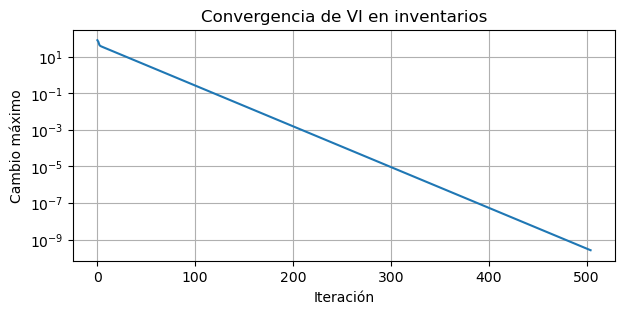

In [22]:
historial_inventario = resultado_vi_inventario[3]

plt.figure(figsize=(7, 3))

plt.semilogy(historial_inventario)

plt.xlabel("Iteración")
plt.ylabel("Cambio máximo")
plt.title("Convergencia de VI en inventarios")
plt.grid()
plt.show()

## Sensibilidad al costo de escasez

Cambiar un parámetro puede modificar el valor óptimo sin modificar la acción que alcanza el máximo. Por eso compararemos tanto la política como $V^*$.

In [23]:
costo_escasez_alternativo = 40

retornos_inventario_alternativo = (
    construir_retornos_inventario(
        precio_venta,
        costo_pedido,
        costo_almacenamiento,
        costo_escasez_alternativo,
        valores_demanda,
        probabilidades_demanda,
        numero_estados_inventario,
        numero_acciones_inventario,
        capacidad_inventario,
        penalizacion_infactible
    )
)

resultado_vi_alternativo = value_iteration(
    matrices_inventario,
    retornos_inventario_alternativo,
    gamma_inventario
)

valor_original = resultado_vi_inventario[0]
politica_original = resultado_vi_inventario[1]

valor_alternativo = resultado_vi_alternativo[0]
politica_alternativa = resultado_vi_alternativo[1]

for inventario_actual in range(numero_estados_inventario):

    print("\nInventario:", inventario_actual)

    print(
        "  Pedido con b=25:",
        politica_original[inventario_actual]
    )

    print(
        "  Pedido con b=40:",
        politica_alternativa[inventario_actual]
    )

    print(
        "  Cambio en V*:",
        round(
            float(
                valor_alternativo[inventario_actual]
                - valor_original[inventario_actual]
            ),
            4
        )
    )


Inventario: 0
  Pedido con b=25: 3
  Pedido con b=40: 3
  Cambio en V*: -0.0

Inventario: 1
  Pedido con b=25: 2
  Pedido con b=40: 2
  Cambio en V*: -0.0

Inventario: 2
  Pedido con b=25: 1
  Pedido con b=40: 1
  Cambio en V*: -0.0

Inventario: 3
  Pedido con b=25: 0
  Pedido con b=40: 0
  Cambio en V*: -0.0

Inventario: 4
  Pedido con b=25: 0
  Pedido con b=40: 0
  Cambio en V*: -0.0


---
# Ejercicio abierto — Gestión de flota de vehículos

Estados:

$$
\mathcal S=
\{\text{Óptimo},\text{Funcional},\text{Desgastado},\text{Crítico}\}.
$$

Acciones:

$$
\mathcal A=
\{\text{Mantener},\text{Reacondicionar}\}.
$$

Transición al mantener:

$$
P^{(M)}
=
\begin{pmatrix}
0.80&0.20&0&0\\
0&0.75&0.25&0\\
0&0&0.65&0.35\\
0&0&0&1
\end{pmatrix}.
$$

Transición al reacondicionar:

$$
P^{(R)}
=
\begin{pmatrix}
1&0&0&0\\
0.80&0.20&0&0\\
0.80&0.20&0&0\\
0.80&0.20&0&0
\end{pmatrix}.
$$

La primera fila es ficticia y válida; la acción Reacondicionar desde Óptimo se penaliza con una recompensa de $-10000$.

Retornos:

| Estado | Mantener | Reacondicionar |
|:---|---:|---:|
| Óptimo | 200 | -10000 |
| Funcional | 160 | -80 |
| Desgastado | 100 | -80 |
| Crítico | 40 | -80 |

Use $\gamma=0.92$.

### Actividades

1. Construya `P` como una lista de dos matrices y `R` como una matriz bidimensional.
2. Resuelva con `value_iteration`, `policy_iteration` y `mdp_linprog`.
3. Compare los resultados con `mostrar_comparacion`.
4. Identifique desde qué estado conviene reacondicionar.
5. Grafique el historial de VI como visualización proporcionada.
6. Repita VI con $\gamma=0.75$ y compare el número de iteraciones.
7. Calcule el número de restricciones del LP:
   $$|\mathcal S||\mathcal A|.$$
8. Para 20 estados y 2 acciones, determine el número de restricciones del LP. Explique por qué **no puede determinarse el número de iteraciones de VI únicamente a partir del número de estados**.
9. Verifique con `jmarkov`.

## Uso crítico de IA

Antes de aceptar el código generado, compruebe:

$$
R[\text{Funcional},\text{Reacondicionar}]
=
200-280
=
-80.
$$

También verifique que:

- todas las filas de las matrices de transición sumen 1;
- la primera fila de Reacondicionar sea `[1, 0, 0, 0]`;
- el código reutilice las funciones ya definidas;
- la IA no afirme que el número de iteraciones de VI puede obtenerse solo a partir de $|\mathcal S|$.

### Prompt sugerido

```text
Estoy resolviendo un MDP de horizonte infinito en Python.

Ya tengo definidas las funciones:
- value_iteration
- policy_iteration
- mdp_linprog
- mostrar_comparacion

Ayúdame a construir los arreglos del ejercicio de flota y a reutilizar
esas funciones. Usa solamente ciclos for, condicionales, funciones sencillas
y arreglos de NumPy.

No uses enumerate, zip, comprensiones de listas, comprensiones de diccionarios,
np.column_stack ni axis=1.

Separa el cálculo de las gráficas. La gráfica de convergencia se entrega como
visualización auxiliar y no hace parte del código central.

Comprueba que R[Funcional, Reacondicionar] sea -80 y que todas las filas de
las matrices de transición sumen 1.

Para el caso de 20 estados y 2 acciones, calcula el número de restricciones
del LP y explica por qué el número de iteraciones de VI no puede deducirse
únicamente del número de estados.
```

In [ ]:
# Desarrolle aquí el ejercicio abierto.
# Comience construyendo los estados, las acciones,
# las dos matrices de transición y la matriz de retornos.


---
<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo</small>